<a href="https://colab.research.google.com/github/GH2023001542/Personal_Finance/blob/main/Personal_Finance.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression

df = pd.read_csv("/content/sample_data/project.csv")
df.head()

,Date,Category,Amount
0,2025-01-01,Food,250
1,2025-01-02,Transport,120
2,2025-01-03,Shopping,800
3,2025-01-05,Bills,1500
4,2025-01-06,Food,300


In [ ]:
# -------- PREPROCESSING --------
df["Date"] = pd.to_datetime(df["Date"])
df["Month"] = df["Date"].dt.month
df.head()

,Date,Category,Amount,Month
0,2025-01-01,Food,250,1
1,2025-01-02,Transport,120,1
2,2025-01-03,Shopping,800,1
3,2025-01-05,Bills,1500,1
4,2025-01-06,Food,300,1


In [ ]:
# -------- ANALYSIS --------
monthly_spending = df.groupby("Month")["Amount"].sum()

print("Monthly Spending:\n", monthly_spending)

Monthly Spending:
 Month
1    5420
2    5570
3    6130
Name: Amount, dtype: int64


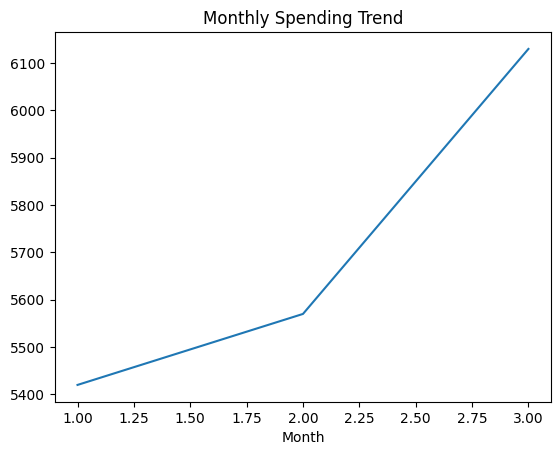

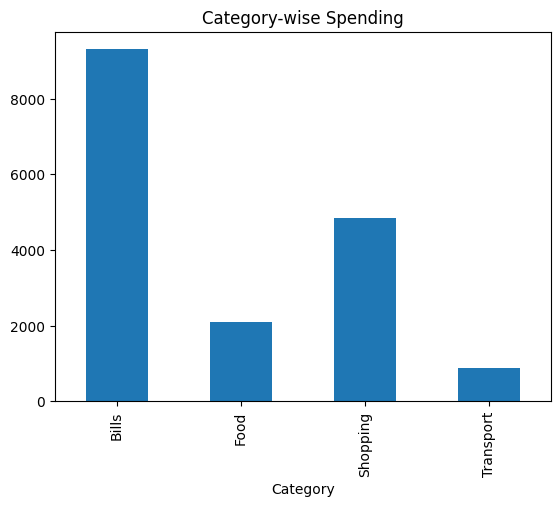

In [ ]:
# -------- VISUALIZATION --------
monthly_spending.plot(title="Monthly Spending Trend")
plt.show()

category_spending = df.groupby("Category")["Amount"].sum()
category_spending.plot(kind='bar', title="Category-wise Spending")
plt.show()


In [ ]:
# -------- OVESPENDING DETECTION --------
threshold = df["Amount"].mean() + df["Amount"].std()
df["Overspending"] = df["Amount"] > threshold

print("\nOverspending Instances:")
print(df[df["Overspending"]])


Overspending Instances:
         Date Category  Amount  Month  Overspending
3  2025-01-05    Bills    1500      1          True
7  2025-01-12    Bills    1400      1          True
12 2025-02-05    Bills    1600      2          True
16 2025-02-15    Bills    1500      2          True
20 2025-03-05    Bills    1700      3          True
24 2025-03-15    Bills    1600      3          True


In [ ]:
# -------- ML MODEL (PREDICT NEXT MONTH) --------
X = df[["Month"]]
y = df["Amount"]

model = LinearRegression()
model.fit(X, y)

next_month = pd.DataFrame({"Month": [df["Month"].max() + 1]})
prediction = model.predict(next_month)

print(f"📈 Predicted Spending for Next Month: {prediction[0]:.2f}")

📈 Predicted Spending for Next Month: 894.35
